# Домашнее задание: Корреляция, значимость признаков и их визуализация

Что нужно сделать:

- Выбери любой регрессионный датасет, проанализируй корреляцию и значимость признаков, сделай отбор и сравни методы.
- Главное: использовать те же методы как на практике, но на другом датасете.

Подготовка:
- Выбери датасет
- Рекомендуемые варианты:
1. California Housing (встроенный в sklearn)
2. Ames Housing (Kaggle)
3. Auto MPG (UCI ML Repository)
4. Или другой регрессионный датасет

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing  # или твой датасет
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import f_regression
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Загрузи свой датасет

TODO: замени на свой датасет если нужно

In [3]:
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Раздели на X и y
X = df.drop('target', axis=1)
y = df['target']

print(f"Признаков: {X.shape}")
print(f"Записей: {X.shape}")
print(X.head())

Признаков: (20640, 8)
Записей: (20640, 8)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


# Задача 1: Корреляционная матрица
Описание: Вычисли корреляцию между всеми признаками и найди топ-5 по корреляции с target.

In [4]:
def calculate_correlation(X, y):
    """
    Вычисляет корреляционную матрицу и находит топ признаков по корреляции с target.

    Args:
        X: DataFrame с признаками
        y: Series с целевой переменной

    Returns:
        corr_matrix: матрица корреляций
        top_features: Series с топ-5 признаков по корреляции
    """
    # TODO: Создай DataFrame с признаками и target

    # TODO: Вычисли корреляционную матрицу (.corr())

    # TODO: Найди корреляцию каждого признака с target

    # TODO: Отсортируй по убыванию и возьми топ-5

    df_corr = X.copy()
    df_corr["target"] = y
    corr_matrix = df_corr.corr()
    target_corr = corr_matrix["target"].drop("target")
    top_features = target_corr.abs().sort_values(ascending=False).head(5)

    return corr_matrix, top_features

# Вызови функцию и выведи результаты
corr_matrix, top_features = calculate_correlation(X, y)
print("Топ-5 признаков по корреляции с target:")
print(top_features)

Топ-5 признаков по корреляции с target:
MedInc       0.688075
AveRooms     0.151948
Latitude     0.144160
HouseAge     0.105623
AveBedrms    0.046701
Name: target, dtype: float64


# Задача 2: Визуализация корреляции (Heatmap)
Описание: Создай тепловую карту корреляционной матрицы.

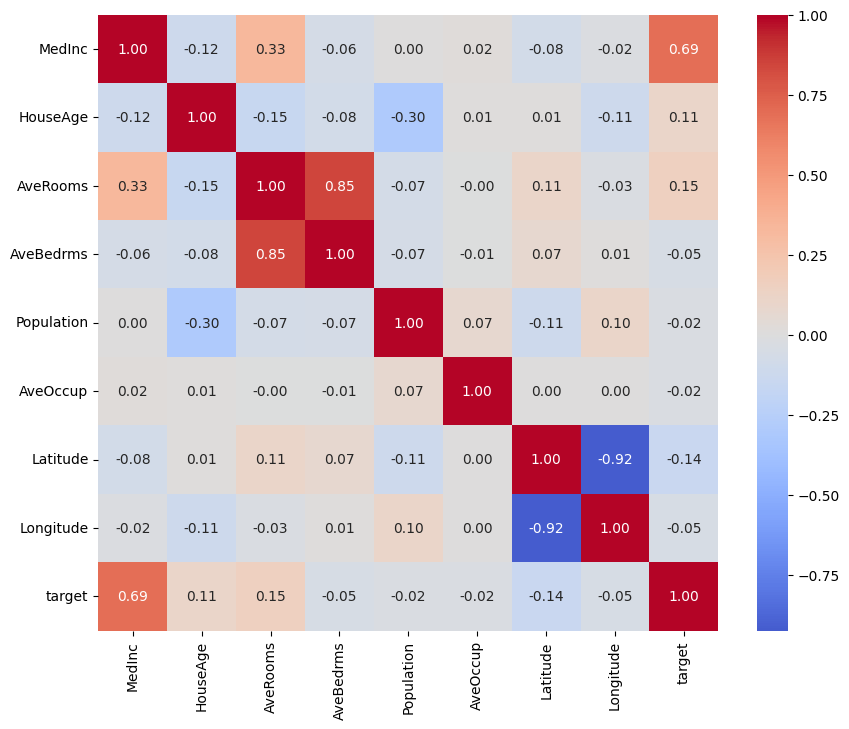

In [6]:
def plot_correlation_heatmap(corr_matrix):
    """
    Создаёт heatmap корреляционной матрицы.

    Args:
        corr_matrix: матрица корреляций
    """
    # TODO: Создай figure с размером (10, 8)

    # TODO: Используй sns.heatmap() с параметрами:
    #       - annot=True (показать числа)
    #       - cmap='coolwarm' (цветовая схема)
    #       - center=0 (центр на нуле)
    #       - fmt='.2f' (формат чисел)

    # TODO: Добавь заголовок

    # TODO: Покажи график (plt.show())

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap='coolwarm',
        center=0,
        fmt=".2f"
    )

# Вызови функцию
plot_correlation_heatmap(corr_matrix)

# Задача 3: Статистическая значимость (p-values)
Описание: Вычисли p-values для каждого признака и подсчитай значимые.

In [7]:
def calculate_significance(X, y):
    """
    Вычисляет статистическую значимость (p-values) для каждого признака.

    Args:
        X: DataFrame с признаками
        y: Series с целевой переменной

    Returns:
        significance_df: DataFrame с F-Score и P-Value для каждого признака
        significant_count: количество значимых признаков (p < 0.05)
    """
    # TODO: Используй f_regression(X, y) для получения f_scores и p_values

    # TODO: Создай DataFrame с колонками: Feature, F-Score, P-Value

    # TODO: Отсортируй по P-Value

    # TODO: Подсчитай сколько признаков с p < 0.05

    f_scores, p_values = f_regression(X, y)
    significance_df = pd.DataFrame({
        "Feature": X.columns,
        "F-Score": f_scores,
        "P-Value": p_values
    })

    significance_df = significance_df.sort_values("P-Value")
    significant_count = (significance_df["P-Value"] < 0.05).sum()

    return significance_df, significant_count

# Вызови функцию и выведи результаты
significance_df, significant_count = calculate_significance(X, y)
print(significance_df)
print(f"\nЗначимых признаков (p < 0.05): {significant_count} из {len(X.columns)}")

      Feature       F-Score        P-Value
0      MedInc  18556.571631   0.000000e+00
2    AveRooms    487.757462  7.569242e-107
6    Latitude    438.005453   2.939859e-96
1    HouseAge    232.841479   2.761861e-52
3   AveBedrms     45.108576   1.912589e-11
7   Longitude     43.698976   3.923322e-11
4  Population     12.547410   3.976308e-04
5    AveOccup     11.635342   6.483442e-04

Значимых признаков (p < 0.05): 8 из 8


# Задача 4: Визуализация p-values (Bar plot)
Описание: Создай bar plot с p-values, где значимые признаки выделены цветом.

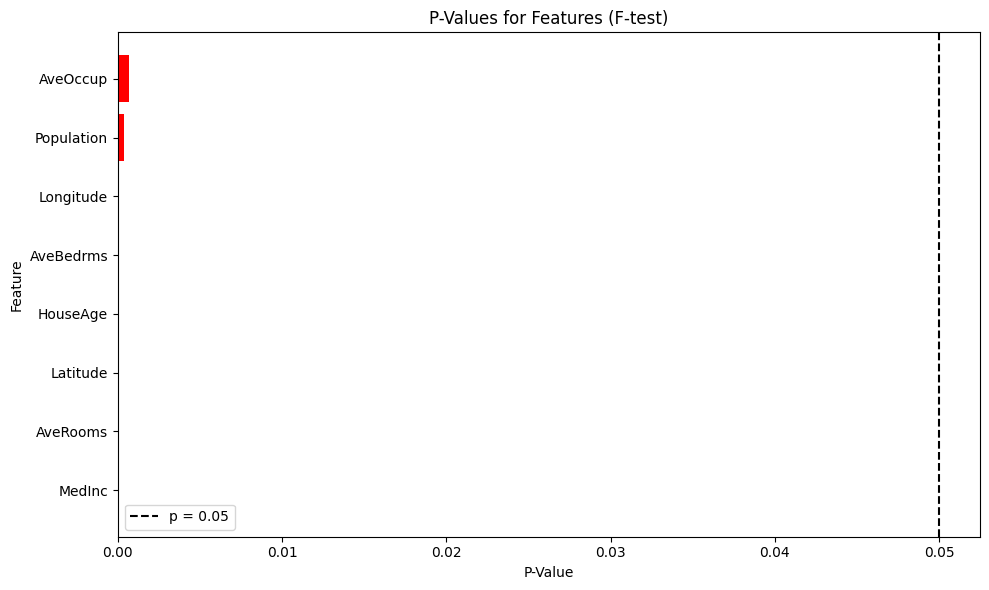

In [8]:
def plot_pvalues(significance_df):
    """
    Создаёт bar plot с p-values для каждого признака.

    Args:
        significance_df: DataFrame с P-Value для каждого признака
    """
    # TODO: Создай figure

    # TODO: Определи цвета: красный если p < 0.05, серый если p >= 0.05

    # TODO: Создай горизонтальный bar plot (plt.barh)

    # TODO: Добавь вертикальную линию на 0.05 (plt.axvline)

    # TODO: Добавь заголовок и подписи осей

    # TODO: Покажи график

    plt.figure(figsize=(10, 6))
    colors = ['red' if p < 0.05 else 'gray' for p in significance_df['P-Value']]
    plt.barh(significance_df['Feature'], significance_df['P-Value'], color=colors)
    plt.axvline(0.05, color='black', linestyle='--', label="p = 0.05")

    plt.xlabel("P-Value")
    plt.ylabel("Feature")
    plt.title("P-Values for Features (F-test)")
    plt.legend()

    plt.tight_layout()
    plt.show()

# Вызови функцию
plot_pvalues(significance_df)

# Задача 5: Feature Importance (RandomForest)
Описание: Обучи RandomForest и получи важность каждого признака.

In [9]:
def calculate_feature_importance(X, y):
    """
    Вычисляет важность признаков с помощью RandomForest.

    Args:
        X: DataFrame с признаками
        y: Series с целевой переменной

    Returns:
        importance_df: DataFrame с Importance и Importance_Pct для каждого признака
        model: обученная модель RandomForest
    """
    # TODO: Создай модель RandomForestRegressor(n_estimators=100, random_state=42)

    # TODO: Обучи модель на X и y

    # TODO: Получи feature_importances_ из модели

    # TODO: Создай DataFrame с колонками: Feature, Importance

    # TODO: Добавь колонку Importance_Pct (проценты от суммы)

    # TODO: Отсортируй по убыванию Importance

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X, y)
    feature_importances = model.feature_importances_
    importance_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": feature_importances
    })

    importance_df["Importance_Pct"] = importance_df["Importance"] / importance_df["Importance"].sum()
    importance_df = importance_df.sort_values("Importance", ascending=False)

    return importance_df, model

# Вызови функцию и выведи результаты
importance_df, rf_model = calculate_feature_importance(X, y)
print(importance_df)
print(f"\nТоп-3 признака:")
print(importance_df.head(3))

      Feature  Importance  Importance_Pct
0      MedInc    0.520037        0.520037
5    AveOccup    0.136406        0.136406
6    Latitude    0.092856        0.092856
7   Longitude    0.092694        0.092694
1    HouseAge    0.052964        0.052964
2    AveRooms    0.044513        0.044513
4  Population    0.031232        0.031232
3   AveBedrms    0.029299        0.029299

Топ-3 признака:
    Feature  Importance  Importance_Pct
0    MedInc    0.520037        0.520037
5  AveOccup    0.136406        0.136406
6  Latitude    0.092856        0.092856


# Задача 6: Визуализация Feature Importance
Описание: Создай bar plot с важностью признаков.

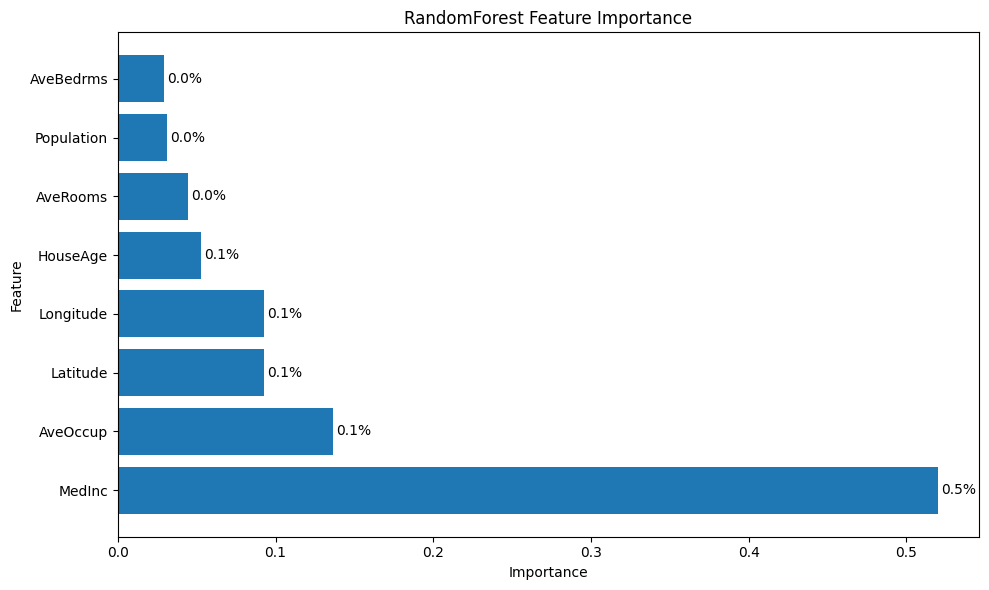

In [13]:
def plot_feature_importance(importance_df):
    """
    Создаёт bar plot с важностью признаков.

    Args:
        importance_df: DataFrame с Importance для каждого признака
    """
    # TODO: Создай figure

    # TODO: Создай горизонтальный bar plot

    # TODO: Добавь значения в процентах на столбцы (plt.text)

    # TODO: Добавь заголовок и подписи осей

    # TODO: Покажи график

    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'], importance_df['Importance_Pct'])
    for index, value in enumerate(importance_df['Importance_Pct']):
        plt.text(
            value + 0.002,
            index,
            f"{value:.1f}%",
            va='center'
        )

        plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title("RandomForest Feature Importance")

    plt.tight_layout()
    plt.show()

# Вызови функцию
plot_feature_importance(importance_df)

# Задача 7: Permutation Importance
Описание: Вычисли permutation importance на test наборе.

In [14]:
def calculate_permutation_importance(X, y):
    """
    Вычисляет permutation importance на test наборе.

    Args:
        X: DataFrame с признаками
        y: Series с целевой переменной

    Returns:
        perm_importance_df: DataFrame с Perm_Importance для каждого признака
    """
    # TODO: Раздели данные на train/test (80/20) с random_state=42

    # TODO: Создай и обучи RandomForest на train

    # TODO: Используй permutation_importance() на test с n_repeats=10

    # TODO: Создай DataFrame с колонками: Feature, Perm_Importance, Perm_Std

    # TODO: Отсортируй по убыванию

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    perm = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=10,
        random_state=42
    )
    perm_importance_df = pd.DataFrame({
        "Feature": X.columns,
        "Perm_Importance": perm.importances_mean,
        "Perm_Std": perm.importances_std
    })

    perm_importance_df = perm_importance_df.sort_values(
        "Perm_Importance", ascending=False
    )

    return perm_importance_df

# Вызови функцию и выведи результаты
perm_importance_df = calculate_permutation_importance(X, y)
print(perm_importance_df)

      Feature  Perm_Importance  Perm_Std
0      MedInc         0.728914  0.014136
6    Latitude         0.443871  0.009470
7   Longitude         0.334467  0.006118
5    AveOccup         0.203054  0.005600
1    HouseAge         0.071809  0.004080
2    AveRooms         0.028274  0.001980
3   AveBedrms         0.009398  0.001396
4  Population         0.008137  0.001337


# Задача 8: Сравнение методов важности
Описание: Сравни Tree Importance и Permutation Importance.


      Feature  Importance  Perm_Importance
0      MedInc    0.520037         0.728914
1    AveOccup    0.136406         0.203054
2    Latitude    0.092856         0.443871
3   Longitude    0.092694         0.334467
4    HouseAge    0.052964         0.071809
5    AveRooms    0.044513         0.028274
6  Population    0.031232         0.008137
7   AveBedrms    0.029299         0.009398


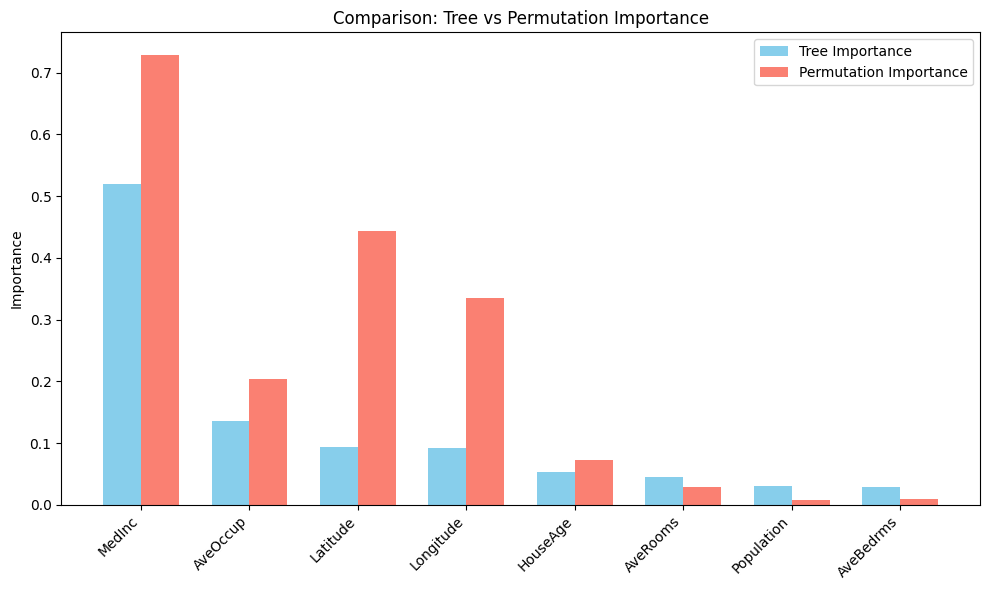

In [16]:
def compare_importance_methods(importance_df, perm_importance_df):
    """
    Сравнивает два метода оценки важности признаков.

    Args:
        importance_df: DataFrame с Tree Importance
        perm_importance_df: DataFrame с Permutation Importance

    Returns:
        comparison_df: DataFrame со сравнением обоих методов
    """
    # TODO: Объедини данные из обоих DataFrame по Feature

    # TODO: Создай comparison_df с колонками: Feature, Tree_Importance, Perm_Importance

    # TODO: Отсортируй по Tree_Importance

    comparison_df = pd.merge(
        importance_df[['Feature', 'Importance']],
        perm_importance_df[['Feature', 'Perm_Importance']],
        on='Feature'
    )
    comparison_df = comparison_df.sort_values('Importance', ascending=False)

    return comparison_df


def plot_importance_comparison(comparison_df):
    """
    Создаёт график сравнения двух методов важности.

    Args:
        comparison_df: DataFrame со сравнением методов
    """
    # TODO: Создай figure

    # TODO: Создай grouped bar plot с двумя рядами столбцов

    # TODO: Добавь легенду, заголовок и подписи

    # TODO: Покажи график

    plt.figure(figsize=(10, 6))
    x = np.arange(len(comparison_df))
    width = 0.35

    plt.bar(x - width/2, comparison_df['Importance'], width, label='Tree Importance', color='skyblue')
    plt.bar(x + width/2, comparison_df['Perm_Importance'], width, label='Permutation Importance', color='salmon')

    plt.xticks(x, comparison_df['Feature'], rotation=45, ha='right')
    plt.ylabel("Importance")
    plt.title("Comparison: Tree vs Permutation Importance")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Вызови функции
comparison_df = compare_importance_methods(importance_df, perm_importance_df)
print(comparison_df)
plot_importance_comparison(comparison_df)

# Задача 9: Отбор признаков (три метода)
Описание: Отбери признаки тремя разными методами.

In [19]:
def select_features_by_correlation(corr_with_target, threshold=0.3):
    """
    Отбирает признаки по корреляции с target.

    Args:
        corr_with_target: Series с корреляциями
        threshold: порог (по умолчанию 0.3)

    Returns:
        selected_features: список выбранных признаков
    """
    # TODO: Выбери признаки где |корреляция| > threshold

    selected_features = corr_with_target[abs(corr_with_target) > threshold].index.tolist()
    return selected_features


def select_features_by_significance(significance_df, threshold=0.05):
    """
    Отбирает признаки по статистической значимости.

    Args:
        significance_df: DataFrame с P-Value
        threshold: порог p-value (по умолчанию 0.05)

    Returns:
        selected_features: список выбранных признаков
    """
    # TODO: Выбери признаки где p-value < threshold

    selected_features = significance_df[significance_df['P-Value'] < threshold]['Feature'].tolist()
    return selected_features


def select_features_by_importance(importance_df, top_pct=0.5):
    """
    Отбирает признаки по важности (топ X%).

    Args:
        importance_df: DataFrame с Importance
        top_pct: какую долю важности покрыть (по умолчанию 0.5 = 50%)

    Returns:
        selected_features: список выбранных признаков
    """
    # TODO: Выбери признаки, которые в сумме дают top_pct от общей важности

    df_sorted = importance_df.sort_values('Importance', ascending=False).copy()
    df_sorted['cum_sum'] = df_sorted['Importance'].cumsum()
    threshold_value = top_pct * df_sorted['Importance'].sum()
    selected_features = df_sorted[df_sorted['cum_sum'] <= threshold_value]['Feature'].tolist()

    # Если ни один признак не попал (очень маленький top_pct), возьмем хотя бы первый
    if len(selected_features) == 0:
        selected_features = [df_sorted['Feature'].iloc[0]]

    return selected_features


# Вызови все три функции
corr_with_target = X.corrwith(y)
selected_corr = select_features_by_correlation(corr_with_target)
selected_sign = select_features_by_significance(significance_df)
selected_imp = select_features_by_importance(importance_df)

print(f"Было признаков: {len(X.columns)}")
print(f"\nМетод 1 (корреляция): {len(selected_corr)} признаков")
print(f"  Выбранные: {selected_corr}")
print(f"\nМетод 2 (значимость): {len(selected_sign)} признаков")
print(f"  Выбранные: {selected_sign}")
print(f"\nМетод 3 (важность): {len(selected_imp)} признаков")
print(f"  Выбранные: {selected_imp}")

# TODO: Найди пересечение всех трёх методов
intersection = list(set(selected_corr) & set(selected_sign) & set(selected_imp))
print(f"\nПересечение всех методов: {intersection}")

Было признаков: 8

Метод 1 (корреляция): 1 признаков
  Выбранные: ['MedInc']

Метод 2 (значимость): 8 признаков
  Выбранные: ['MedInc', 'AveRooms', 'Latitude', 'HouseAge', 'AveBedrms', 'Longitude', 'Population', 'AveOccup']

Метод 3 (важность): 1 признаков
  Выбранные: ['MedInc']

Пересечение всех методов: ['MedInc']


# Задача 10: Сравнение моделей
Описание: Обучи 4 модели на разных наборах признаков и сравни метрики.

In [22]:
def compare_models(X, y, feature_sets):
    """
    Сравнивает модели, обученные на разных наборах признаков.

    Args:
        X: DataFrame с признаками
        y: Series с целевой переменной
        feature_sets: dict с наборами признаков {'название': [список признаков]}

    Returns:
        results_df: DataFrame с метриками для каждой модели
    """
    # TODO: Раздели данные на train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    results = []

    for name, features in feature_sets.items():
        # TODO: Выбери только нужные признаки

        # TODO: Обучи RandomForest

        # TODO: Сделай предсказания на test

        # TODO: Вычисли метрики: R², MAE, MSE, RMSE

        # TODO: Добавь результаты в список

        X_train_subset = X_train[features]
        X_test_subset = X_test[features]

        model = RandomForestRegressor(n_estimators=100, random_state=42)
        model.fit(X_train_subset, y_train)

        y_pred = model.predict(X_test_subset)
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)

        results.append({
            "Model": name,
            "R2": r2,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse
        })

    results_df = pd.DataFrame(results)
    return results_df

# Подготовь наборы признаков
feature_sets = {
    'Все признаки': list(X.columns),
    'По корреляции': selected_corr,
    'По значимости': selected_sign,
    'По важности': selected_imp
}

# Вызови функцию
results_df = compare_models(X, y, feature_sets)
print(results_df)

# TODO: Найди лучшую модель по R²
best_model = results_df.loc[results_df['R2'].idxmax(), 'Model']
print(f"\n Лучшая модель: {best_model}")

           Model        R2       MAE       MSE     RMSE
0   Все признаки  0.805123  0.327543  0.255368  0.50534
1  По корреляции  0.281713  0.713167  0.941250  0.97018
2  По значимости  0.804041  0.328252  0.256786  0.50674
3    По важности  0.281713  0.713167  0.941250  0.97018

 Лучшая модель: Все признаки
